# Exploratory Data Analysis (EDA)

1. **Understand the well logs**
    - Familiarize yourself with the different types of well logs available (e.g., gamma ray, resistivity, density, neutron porosity).
    - Identify which logs are most relevant to the analysis.
2. **Data Cleaning**
    - Check for missing values and decide on a strategy to handle them (e.g., imputation, removal).
    - Identify and handle outliers that may skew the analysis.
    - Ensure that all data is in the correct format and units.
3. **Statistical Summary**
    - Generate summary statistics (mean, median, standard deviation, min, max) for each well log.
    - Analyze the distribution of each log using histograms or density plots.

In [19]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../slide/database/features.db')
query = "SELECT channel, COUNT(well) as total_wells FROM LogsChannels GROUP BY channel ORDER BY total_wells DESC"
df = pd.read_sql_query(query, conn)


## Understanding Well Logs

The strategy was to first familiarize ourselves with the different types of well logs available in the dataset. This included identifying key logs such as gamma ray, resistivity, density, and neutron porosity, which are crucial for geological and petrophysical analysis. In order to achieve this goal, we reviewed the well log documentation and consulted domain experts to understand the significance of each log type. The paretto principle was applied here, focusing on the most informative logs that would provide the majority of insights for our analysis. The following table contains a brief description of the key well logs identified and chosen for further analysis. 

| name | name extended | scale | unit |
|------|----------------|-------|------|
| GR   | Gamma Ray      | 0 - 150 | API  |
| SP   | Spontaneous Potential | -100 to +100 | mV   |
| DT   | Sonic (Compressional slowness) | 40 - 140 | µs/ft |
| CALI | Caliper        | 6 - 16 | inches |
| ILD  | Deep Induction Resistivity | 0.2 - 2000 (logarithmic scale) | ohm·m |
| RHOB | Bulk Density | 1.95 - 2.95 | g/cm³ |
| NPHI | Neutron Porosity | 0 - 0.45 (sometimes plotted reverse, 45-0) | fraction (v/v) |
| MSFL | Micro Spherically Focused Log | 0.2 - 2000 (logarithmic scale) | ohm·m |
| DRHO | Density Correction | -0.1 - +0.3 | g/cm³ |
| SFLU | Shallow Laterolog (Unfocused) | 0.2 - 2000 (logarithmic scale) | ohm·m |

These logs were selected based on how frequently they are present in the dataset and their relevance to common geological interpretations. By focusing on these key logs, we aimed to streamline our analysis and extract meaningful insights efficiently.

the markdown formula below shows how to calculate the paretto chart:


1. Sort the data in descending order.
2. Calculate the cumulative sum of the values.
3. Calculate the cumulative percentage of the total.
4. Plot the sorted values as bars and the cumulative percentage as a line.

$$y_i = \frac{x_i}{\sum_{j=1}^{n} x_j} \times 100$$


In [20]:
import plotly.graph_objs as go
import plotly.offline as pyo

# Calculate cumulative percentage for Pareto chart
df['cumsum'] = df['total_wells'].cumsum()
df['cumperc'] = (df['cumsum'] / df['total_wells'].sum()) * 100

# Create bar trace for total_wells
bar_trace = go.Bar(
    x=df['channel'],
    y=df['total_wells'],
    name='Total Wells',
    marker=dict(color='rgba(31, 119, 180, 0.7)')
)

# Create line trace for cumulative percentage
line_trace = go.Scatter(
    x=df['channel'],
    y=df['cumperc'],
    name='Cumulative Percentage',
    yaxis='y2',
    mode='lines+markers',
    line=dict(color='orange', width=2)
)

layout = go.Layout(
    title='Interactive Pareto Chart of Channels by Total Wells',
    xaxis=dict(title='Channel', tickangle=45),
    yaxis=dict(title='Total Wells', showgrid=False),
    yaxis2=dict(
        title='Cumulative Percentage (%)',
        overlaying='y',
        side='right',
        range=[0, 110],
        showgrid=False
    ),
    legend=dict(x=0.75, y=1.15, orientation='h'),
    margin=dict(b=120),
    width=1000,
    height=600
)

fig_plotly = go.Figure(data=[bar_trace, line_trace], layout=layout)
pyo.iplot(fig_plotly)

In [21]:
"""
GR |	Gamma Ray	| 0 - 150 | API
SP |	Spontaneous Potential	| -100 to +100	mV
DT |	Sonic (Compressional slowness)	| 40 - 140	µs/ft
CALI |	Caliper	| 6 - 16	inches
ILD |	Deep Induction Resistivity	| 0.2 - 2000 (logarithmic scale)	ohm·m
RHOB |	Bulk Density	| 1.95 - 2.95	g/cm³
NPHI |	Neutron Porosity	| 0 - 0.45 (sometimes plotted reverse, 45-0)	| fraction (v/v)
MSFL |	Micro Spherically Focused Log	| 0.2 - 2000 (logarithmic scale)	| ohm·m
DRHO |	Density Correction	| -0.1 - +0.3	| g/cm³
SFLU |	Shallow Laterolog (Unfocused)	| 0.2 - 2000 (logarithmic scale)	| ohm·m
"""

'\nGR |\tGamma Ray\t| 0 - 150 | API\nSP |\tSpontaneous Potential\t| -100 to +100\tmV\nDT |\tSonic (Compressional slowness)\t| 40 - 140\tµs/ft\nCALI |\tCaliper\t| 6 - 16\tinches\nILD |\tDeep Induction Resistivity\t| 0.2 - 2000 (logarithmic scale)\tohm·m\nRHOB |\tBulk Density\t| 1.95 - 2.95\tg/cm³\nNPHI |\tNeutron Porosity\t| 0 - 0.45 (sometimes plotted reverse, 45-0)\t| fraction (v/v)\nMSFL |\tMicro Spherically Focused Log\t| 0.2 - 2000 (logarithmic scale)\t| ohm·m\nDRHO |\tDensity Correction\t| -0.1 - +0.3\t| g/cm³\nSFLU |\tShallow Laterolog (Unfocused)\t| 0.2 - 2000 (logarithmic scale)\t| ohm·m\n'

## Data Cleaning

Data cleaning is a crucial step in the EDA process to ensure the quality and reliability of the analysis. The following steps were taken to clean the well log data:
1. **Handling Missing Values**: 
    - Identified missing values in the dataset using methods such as `isnull()` or `isna()`.
    - Decided on an imputation strategy based on the nature of the data. For instance, using mean or median imputation for continuous variables, or removing rows/columns with excessive missing values.

In [34]:
query = "SELECT * FROM Features limit 1000000;"
df_features = pd.read_sql_query(query, conn)
df_features

,well,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,DRHO,SFLU,top,bottom,rock
0,1BT2AM,270.0,63.279785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
1,1BT2AM,270.2,62.580566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
2,1BT2AM,270.4,64.454590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
3,1BT2AM,270.6,65.624268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
4,1BT2AM,270.8,64.920898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,3PIR7AL,1788.2,105.457748,-3.301666,74.474747,-999.25,4.499398,-999.25,-999.25,NaN,-999.25,4.040940,1782.0,1790.0,FOLHELHO
999996,3PIR7AL,1788.4,98.367188,-5.609985,69.902344,-999.25,4.501740,-999.25,-999.25,NaN,-999.25,5.707031,1782.0,1790.0,FOLHELHO
999997,3PIR7AL,1788.6,98.895508,-6.745575,69.823212,-999.25,4.713235,-999.25,-999.25,NaN,-999.25,7.059439,1782.0,1790.0,FOLHELHO
999998,3PIR7AL,1788.8,-999.250000,NaN,NaN,-999.25,NaN,-999.25,-999.25,NaN,-999.25,NaN,1782.0,1790.0,FOLHELHO


Characteristics of missing values in the dataset:
The values -999.25 and NaN are used to represent missing data in the well log dataset. The presence of these values can significantly impact the analysis and interpretation of the data.


In [35]:
print("Dataset Shape:", df_features.shape)
print("\nColumn Names:")
print(df_features.columns.tolist())
df_features.info()
df_features.describe()

Dataset Shape: (1000000, 15)

Column Names:
['well', 'depth', 'GR', 'SP', 'DT', 'CALI', 'ILD', 'RHOB', 'NPHI', 'MSFL', 'DRHO', 'SFLU', 'top', 'bottom', 'rock']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   well    1000000 non-null  object 
 1   depth   1000000 non-null  float64
 2   GR      895199 non-null   float64
 3   SP      681732 non-null   float64
 4   DT      348111 non-null   float64
 5   CALI    542945 non-null   float64
 6   ILD     556803 non-null   float64
 7   RHOB    462454 non-null   float64
 8   NPHI    349707 non-null   float64
 9   MSFL    37970 non-null    float64
 10  DRHO    458137 non-null   float64
 11  SFLU    277438 non-null   float64
 12  top     763708 non-null   float64
 13  bottom  763708 non-null   float64
 14  rock    763708 non-null   object 
dtypes: float64(13), object(2)
memory usage: 114.4+ MB


,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,DRHO,SFLU,top,bottom
count,1000000.000000,895199.000000,681732.000000,348111.000000,542945.000000,556803.000000,462454.000000,349707.000000,37970.000000,458137.000000,277438.000000,763708.000000,763708.000000
mean,2628.180389,-204.921188,-143.405334,-109.941574,-187.753577,-106.677577,-207.677053,-323.466970,-450.959500,-222.401186,-173.510507,1424.764031,1438.812599
std,2499.114037,467.641190,321.055746,414.407853,1044.711742,2281.120868,407.831778,481.722092,501.557987,1129.106773,576.678128,904.390223,907.683394
min,0.400000,-999.250000,-999.250000,-1713.000000,-99998.937500,-999.250000,-999.250000,-999.250000,-999.250000,-99998.937500,-999.250000,3.000000,12.000000
25%,902.000000,-999.250000,-57.752510,60.837944,8.492188,2.216504,2.161276,-999.250000,-999.250000,-0.002857,1.421315,718.000000,729.000000
50%,1704.400000,54.531448,-33.788864,72.402344,9.475410,5.178293,2.403656,11.579561,0.533691,0.024998,5.731819,1305.000000,1313.000000
75%,3412.000000,83.996712,-14.998713,86.822334,12.140625,9.657000,2.535430,22.571152,2.417175,0.073486,12.292881,1997.000000,2007.000000
max,15427.657480,511.799805,444.721680,286.375000,28.207504,1000000.000000,107.115784,107.115784,1956.429443,6.589399,9696.000000,4731.000000,5049.500000


In [36]:
# Check for missing values and data quality issues
import numpy as np

print("Missing Values Analysis:")
print("=" * 50)

missing_data = pd.DataFrame({
    'Column': df_features.columns,
    'Missing_Count': df_features.isnull().sum(),
    'Missing_Percentage': (df_features.isnull().sum() / len(df_features)) * 100,
    'Data_Type': df_features.dtypes
})

# Check for infinite values in numeric columns
numeric_columns = df_features.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    inf_count = np.isinf(df_features[col]).sum()
    missing_data.loc[missing_data['Column'] == col, 'Infinite_Values'] = inf_count

# Sort by missing percentage
missing_data = missing_data.sort_values('Missing_Percentage', ascending=False)
print(missing_data)

Missing Values Analysis:
        Column  Missing_Count  Missing_Percentage Data_Type  Infinite_Values
MSFL      MSFL         962030             96.2030   float64              0.0
SFLU      SFLU         722562             72.2562   float64              0.0
DT          DT         651889             65.1889   float64              0.0
NPHI      NPHI         650293             65.0293   float64              0.0
DRHO      DRHO         541863             54.1863   float64              0.0
RHOB      RHOB         537546             53.7546   float64              0.0
CALI      CALI         457055             45.7055   float64              0.0
ILD        ILD         443197             44.3197   float64              0.0
SP          SP         318268             31.8268   float64              0.0
bottom  bottom         236292             23.6292   float64              0.0
top        top         236292             23.6292   float64              0.0
rock      rock         236292             23.6292  

Excluded columns: ['depth', 'top', 'bottom']
Analyzing 10 columns: ['GR', 'SP', 'DT', 'CALI', 'ILD', 'RHOB', 'NPHI', 'MSFL', 'DRHO', 'SFLU']


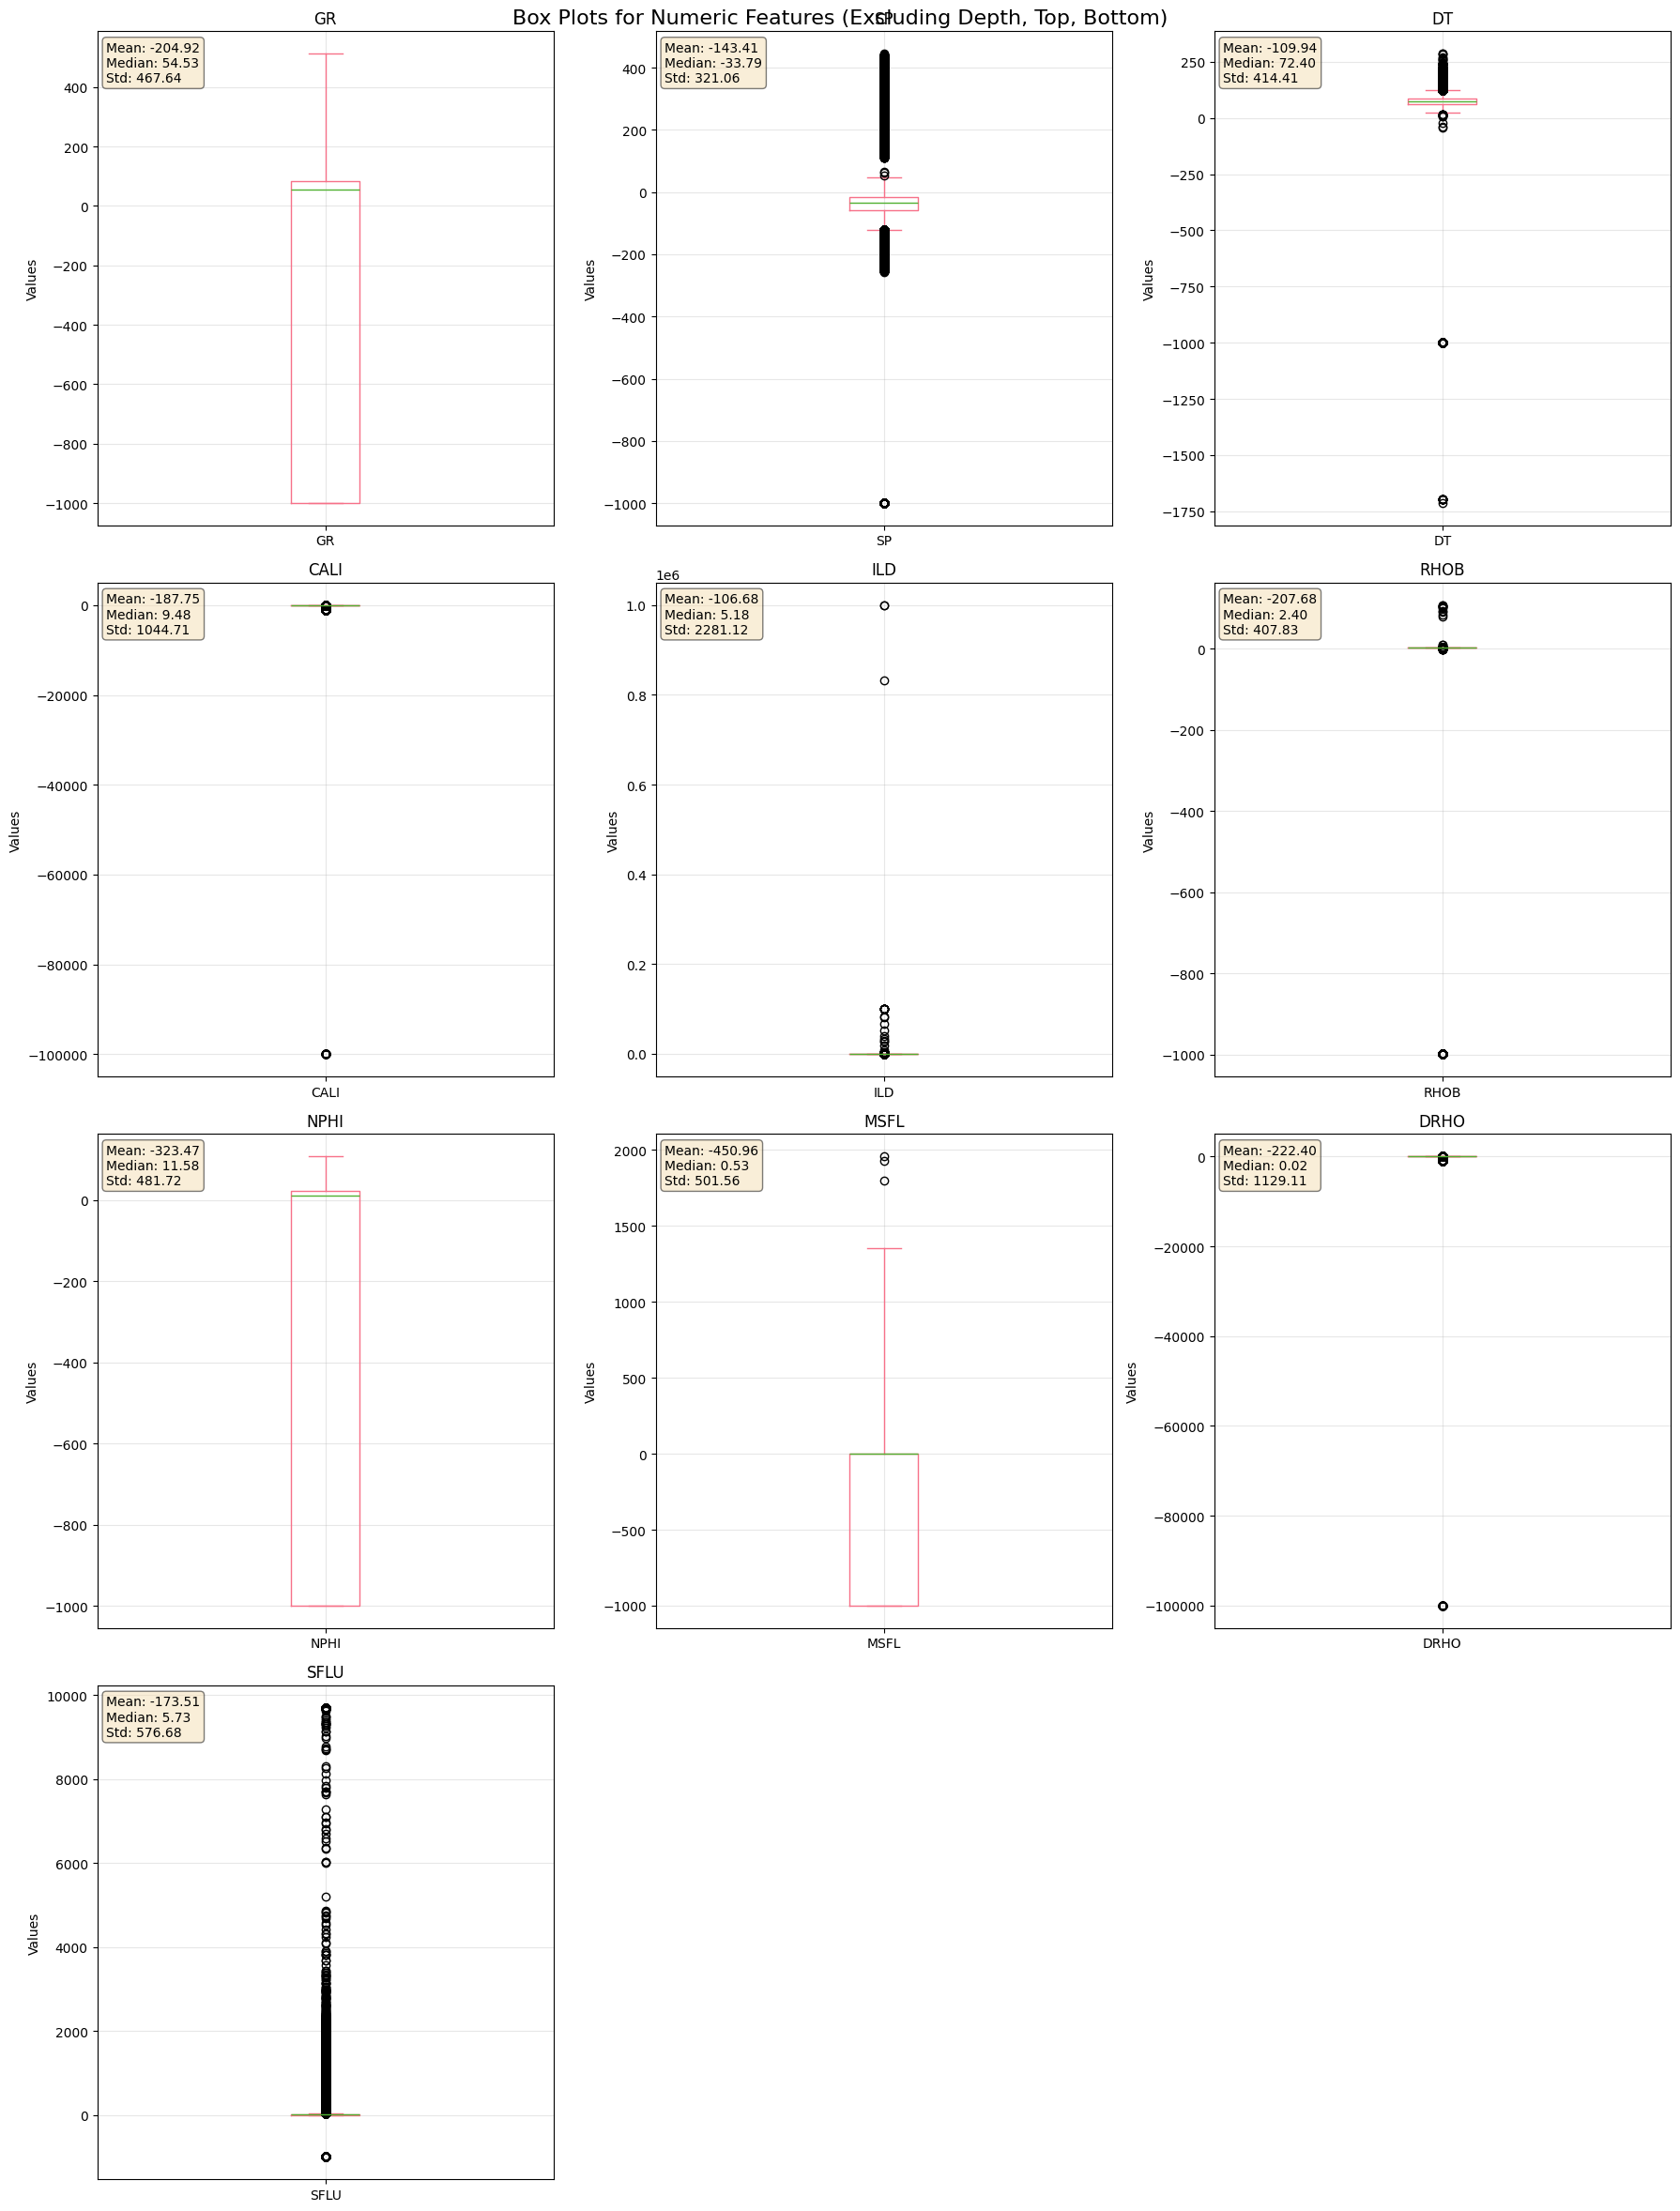

In [25]:
# Create box plots for all numeric columns (excluding depth, top, bottom)
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out depth, top, and bottom columns
columns_to_exclude = ['depth', 'top', 'bottom', 'well']
filtered_numeric_columns = [col for col in numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

print(f"Excluded columns: {[col for col in numeric_columns if col.lower() in [c.lower() for c in columns_to_exclude]]}")
print(f"Analyzing {len(filtered_numeric_columns)} columns: {filtered_numeric_columns}")

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Calculate number of filtered numeric columns and create subplots
n_cols = len(filtered_numeric_columns)
n_rows = (n_cols + 2) // 3  # 3 columns per row
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6 * n_rows))
fig.suptitle('Box Plots for Numeric Features (Excluding Depth, Top, Bottom)', fontsize=16, y=0.98)

# Handle single subplot case
if n_cols == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes if n_cols > 1 else [axes]
else:
    axes = axes.flatten()

# Create box plots
for i, col in enumerate(filtered_numeric_columns):
    ax = axes[i] if n_cols > 1 else axes[0]
    
    # Create box plot
    df_features[col].plot(kind='box', ax=ax, title=f'{col}')
    ax.set_ylabel('Values')
    ax.grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f'Mean: {df_features[col].mean():.2f}\nMedian: {df_features[col].median():.2f}\nStd: {df_features[col].std():.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide unused subplots
for i in range(len(filtered_numeric_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Knowing the standard ranges of well log measurements is essential for interpreting the data accurately. The table above highlights the typical ranges for various well logs, which can help identify anomalies or outliers in the dataset. For example, gamma ray values typically range from 0 to 150 API units, while bulk density values usually fall between 1.95 and 2.95 g/cm³. Understanding these ranges allows for better data validation and quality control during the cleaning process. Let's change any value more than 1.5 standard deviations from the mean to NaN.


In [37]:
# Outlier detection using IQR method
print("Outlier Analysis using IQR Method:")
print("=" * 50)

outlier_summary = []

for col in numeric_columns:
    Q1 = df_features[col].quantile(0.25)
    Q3 = df_features[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = df_features[(df_features[col] < lower_bound) | (df_features[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df_features)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Total_Values': len(df_features[col].dropna()),
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': outlier_percentage,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Q1': Q1,
        'Q3': Q3
    })
    
    print(f"\n{col}:")
    print(f"  - Total valid values: {len(df_features[col].dropna())}")
    print(f"  - Outliers: {outlier_count} ({outlier_percentage:.2f}%)")
    print(f"  - IQR bounds: [{lower_bound:.4f}, {upper_bound:.4f}]")

# Create DataFrame for outlier summary
outlier_df = pd.DataFrame(outlier_summary)
print("\n\nOutlier Summary Table:")
print(outlier_df.round(4))

Outlier Analysis using IQR Method:

depth:
  - Total valid values: 1000000
  - Outliers: 94829 (9.48%)
  - IQR bounds: [-2863.0000, 7177.0000]

GR:
  - Total valid values: 895199
  - Outliers: 0 (0.00%)
  - IQR bounds: [-2624.1201, 1708.8668]

SP:
  - Total valid values: 681732
  - Outliers: 112812 (11.28%)
  - IQR bounds: [-121.8832, 49.1320]

DT:
  - Total valid values: 348111
  - Outliers: 80010 (8.00%)
  - IQR bounds: [21.8614, 125.7989]

CALI:
  - Total valid values: 542945
  - Outliers: 126061 (12.61%)
  - IQR bounds: [3.0195, 17.6133]

ILD:
  - Total valid values: 556803
  - Outliers: 121798 (12.18%)
  - IQR bounds: [-8.9442, 20.8177]

RHOB:
  - Total valid values: 462454
  - Outliers: 97681 (9.77%)
  - IQR bounds: [1.6000, 3.0967]

NPHI:
  - Total valid values: 349707
  - Outliers: 0 (0.00%)
  - IQR bounds: [-2531.9817, 1555.3029]

MSFL:
  - Total valid values: 37970
  - Outliers: 3 (0.00%)
  - IQR bounds: [-2501.7508, 1504.9179]

DRHO:
  - Total valid values: 458137
  - Outlie

In [40]:
df_features.columns

Index(['well', 'depth', 'GR', 'SP', 'DT', 'CALI', 'ILD', 'RHOB', 'NPHI',
       'MSFL', 'DRHO', 'SFLU', 'top', 'bottom', 'rock'],
      dtype='object')

In [41]:
non_numeric_columns = df_features.select_dtypes(exclude=[np.number]).columns

# Summary report of data quality issues
print("DATA QUALITY SUMMARY REPORT")
print("=" * 50)

total_rows = len(df_features)
total_cols = len(df_features.columns)

print(f"Dataset Overview:")
print(f"  - Total rows: {total_rows:,}")
print(f"  - Total columns: {total_cols}")
print(f"  - Numeric columns: {len(numeric_columns)}")
print(f"  - Non-numeric columns: {len(non_numeric_columns)}")

print(f"\nData Quality Issues:")
# Count columns with missing values
cols_with_missing = (df_features.isnull().sum() > 0).sum()
print(f"  - Columns with missing values: {cols_with_missing}/{total_cols}")

# Count total missing values
total_missing = df_features.isnull().sum().sum()
missing_percentage = (total_missing / (total_rows * total_cols)) * 100
print(f"  - Total missing values: {total_missing:,} ({missing_percentage:.2f}%)")

# Count columns with infinite values
cols_with_inf = 0
total_inf = 0
for col in numeric_columns:
    inf_count = np.isinf(df_features[col]).sum()
    if inf_count > 0:
        cols_with_inf += 1
        total_inf += inf_count

print(f"  - Columns with infinite values: {cols_with_inf}")
print(f"  - Total infinite values: {total_inf}")

# Count columns with potential outliers
cols_with_outliers = sum(1 for item in outlier_summary if item['Outlier_Count'] > 0)
total_outliers = sum(item['Outlier_Count'] for item in outlier_summary)
print(f"  - Columns with outliers (IQR method): {cols_with_outliers}/{len(numeric_columns)}")
print(f"  - Total outlier values: {total_outliers:,}")

print(f"\nRecommendations:")
if total_missing > 0:
    print("  - Consider handling missing values through imputation or removal")
if total_inf > 0:
    print("  - Address infinite values before analysis")
if total_outliers > total_rows * 0.05:  # If more than 5% outliers
    print("  - Investigate outliers - they may indicate data quality issues or interesting patterns")
if len(numeric_columns) > 10:
    print("  - Consider dimensionality reduction techniques for high-dimensional data")

print("\nAnalysis complete! Review the visualizations and statistics above for detailed insights.")

DATA QUALITY SUMMARY REPORT
Dataset Overview:
  - Total rows: 1,000,000
  - Total columns: 15
  - Numeric columns: 13
  - Non-numeric columns: 2

Data Quality Issues:
  - Columns with missing values: 13/15
  - Total missing values: 6,098,380 (40.66%)
  - Columns with infinite values: 0
  - Total infinite values: 0
  - Columns with outliers (IQR method): 11/13
  - Total outlier values: 868,592

Recommendations:
  - Consider handling missing values through imputation or removal
  - Investigate outliers - they may indicate data quality issues or interesting patterns
  - Consider dimensionality reduction techniques for high-dimensional data

Analysis complete! Review the visualizations and statistics above for detailed insights.


In [ ]:
df_features_filtered = df_features.copy()

# Replace outliers with NaN
for col in numeric_columns:
    if col == "GR":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 0) | (df_features_filtered[col] > 200), np.nan, df_features_filtered[col])
    elif col == "SP":
        df_features_filtered[col] = np.where((df_features_filtered[col] < -100) | (df_features_filtered[col] > 100), np.nan, df_features_filtered[col])
    elif col == "DT":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 40) | (df_features_filtered[col] > 140), np.nan, df_features_filtered[col])
    elif col == "CALI":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 6) | (df_features_filtered[col] > 16), np.nan, df_features_filtered[col])
    elif col == "ILD":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 0.2) | (df_features_filtered[col] > 2000), np.nan, df_features_filtered[col])
    elif col == "RHOB":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 1.95) | (df_features_filtered[col] > 2.95), np.nan, df_features_filtered[col])
    elif col == "NPHI":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 0) | (df_features_filtered[col] > 0.45), np.nan, df_features_filtered[col])
    elif col == "MSFL":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 0.2) | (df_features_filtered[col] > 2000), np.nan, df_features_filtered[col])
    elif col == "DRHO":
        df_features_filtered[col] = np.where((df_features_filtered[col] < -0.1) | (df_features_filtered[col] > 0.3), np.nan, df_features_filtered[col])
    elif col == "SFLU":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 0.2) | (df_features_filtered[col] > 2000), np.nan, df_features_filtered[col])

df_features_filtered.describe()


,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,DRHO,SFLU,top,bottom
count,1000000.000000,663835.000000,559598.000000,274282.000000,405858.000000,484782.000000,359782.000000,694.000000,20697.000000,360807.000000,211845.000000,763708.000000,763708.000000
mean,2628.180389,68.657219,-29.796024,79.454698,10.570919,16.715606,2.450975,0.226148,6.624779,0.063885,58.187587,1424.764031,1438.812599
std,2499.114037,36.952135,22.406872,17.256518,1.900508,94.249221,0.147991,0.130741,34.920636,0.066575,262.547742,904.390223,907.683394
min,0.400000,0.000000,-99.997986,40.000000,6.077258,0.201597,1.950054,0.000000,0.225098,-0.099896,0.229858,3.000000,12.000000
25%,902.000000,44.714020,-45.144196,67.255821,8.935061,3.405273,2.355713,0.118920,0.784668,0.014000,4.698598,718.000000,729.000000
50%,1704.400000,69.781998,-28.670006,75.733414,9.943123,6.002999,2.461975,0.220288,1.957779,0.041000,7.894531,1305.000000,1313.000000
75%,3412.000000,92.366989,-13.561481,88.242188,12.142834,10.679688,2.564814,0.340750,6.351562,0.092350,15.377369,1997.000000,2007.000000
max,15427.657480,200.000000,64.203094,140.000000,16.000000,2000.000000,2.949828,0.449642,1956.429443,0.300000,2000.000000,4731.000000,5049.500000


In [43]:
df_features_filtered

,well,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,DRHO,SFLU,top,bottom,rock
0,1BT2AM,270.0,63.279785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
1,1BT2AM,270.2,62.580566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
2,1BT2AM,270.4,64.454590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
3,1BT2AM,270.6,65.624268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
4,1BT2AM,270.8,64.920898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,3PIR7AL,1788.2,105.457748,-3.301666,74.474747,NaN,4.499398,NaN,NaN,NaN,NaN,4.040940,1782.0,1790.0,FOLHELHO
999996,3PIR7AL,1788.4,98.367188,-5.609985,69.902344,NaN,4.501740,NaN,NaN,NaN,NaN,5.707031,1782.0,1790.0,FOLHELHO
999997,3PIR7AL,1788.6,98.895508,-6.745575,69.823212,NaN,4.713235,NaN,NaN,NaN,NaN,7.059439,1782.0,1790.0,FOLHELHO
999998,3PIR7AL,1788.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1782.0,1790.0,FOLHELHO


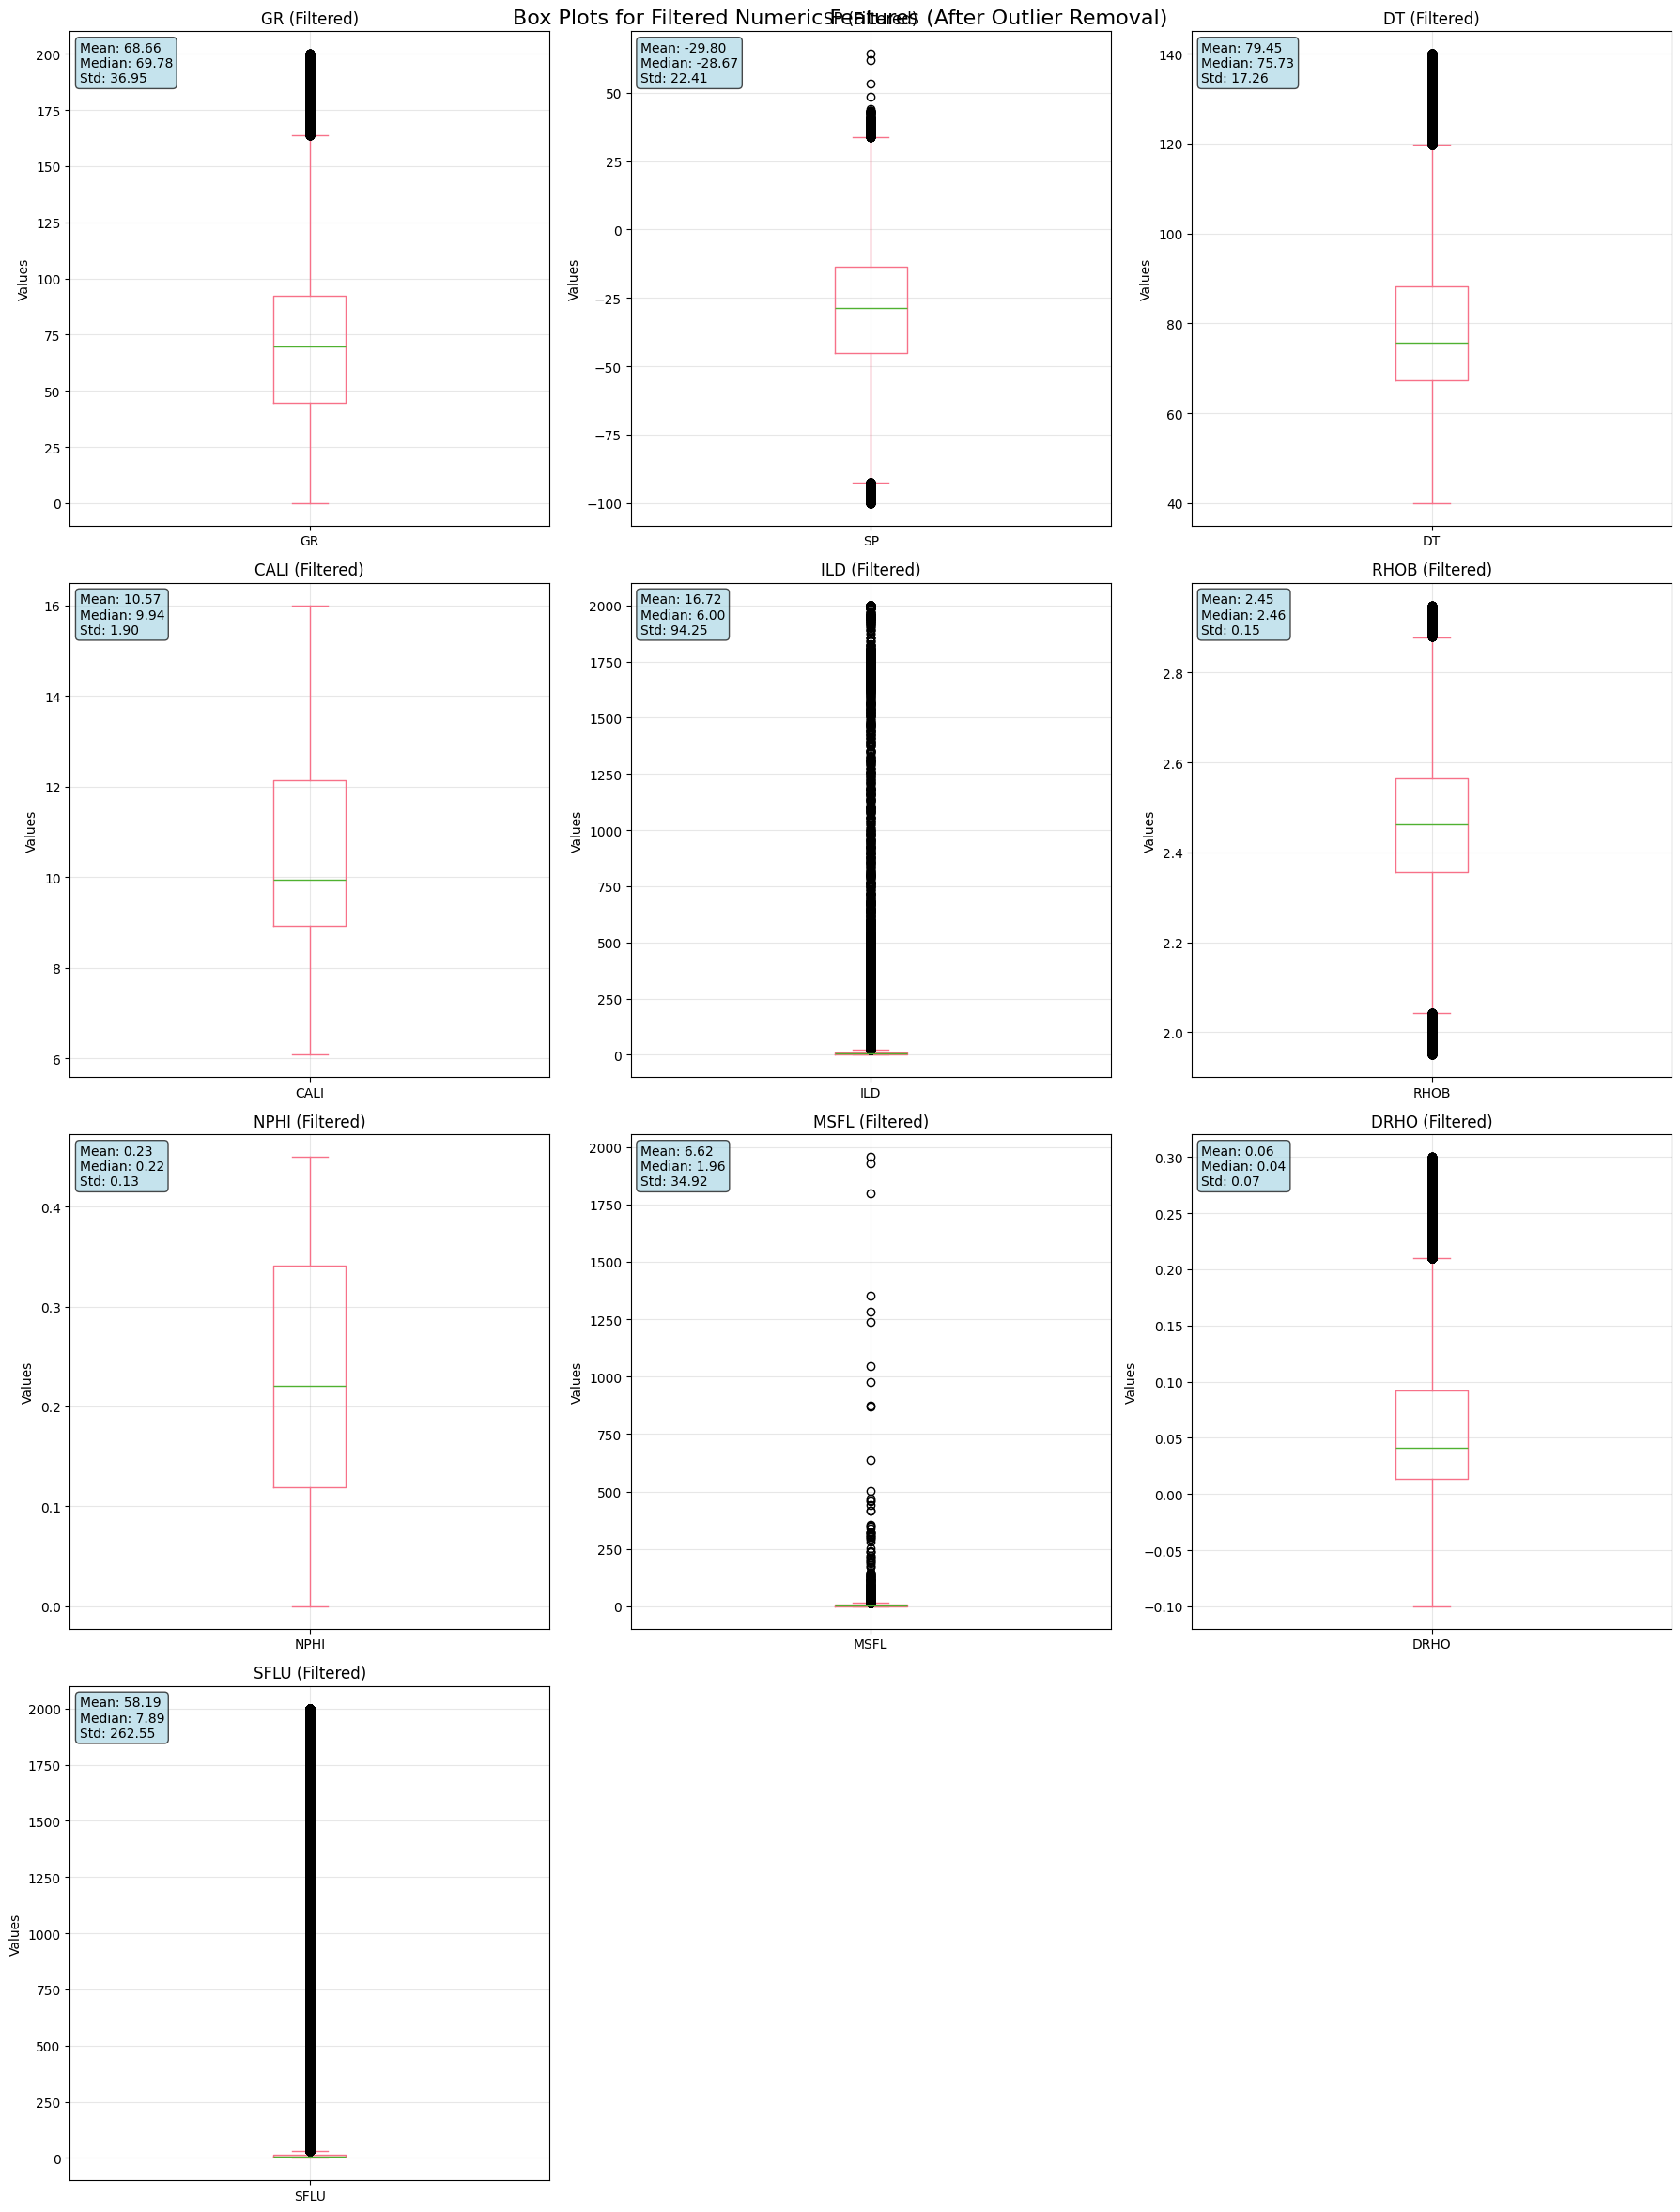

In [30]:
# Create box plots for the filtered numeric columns (excluding depth, top, bottom)
filtered_numeric_columns_clean = [col for col in filtered_numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

n_cols_clean = len(filtered_numeric_columns_clean)
n_rows_clean = (n_cols_clean + 2) // 3  # 3 columns per row
fig, axes = plt.subplots(n_rows_clean, 3, figsize=(18, 6 * n_rows_clean))
fig.suptitle('Box Plots for Filtered Numeric Features (After Outlier Removal)', fontsize=16, y=0.98)

# Handle single subplot case
if n_cols_clean == 1:
    axes = [axes]
elif n_rows_clean == 1:
    axes = axes if n_cols_clean > 1 else [axes]
else:
    axes = axes.flatten()

# Create box plots for filtered data
for i, col in enumerate(filtered_numeric_columns_clean):
    ax = axes[i] if n_cols_clean > 1 else axes[0]
    
    # Create box plot
    df_features_filtered[col].plot(kind='box', ax=ax, title=f'{col} (Filtered)')
    ax.set_ylabel('Values')
    ax.grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f'Mean: {df_features_filtered[col].mean():.2f}\nMedian: {df_features_filtered[col].median():.2f}\nStd: {df_features_filtered[col].std():.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Hide unused subplots
for i in range(len(filtered_numeric_columns_clean), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

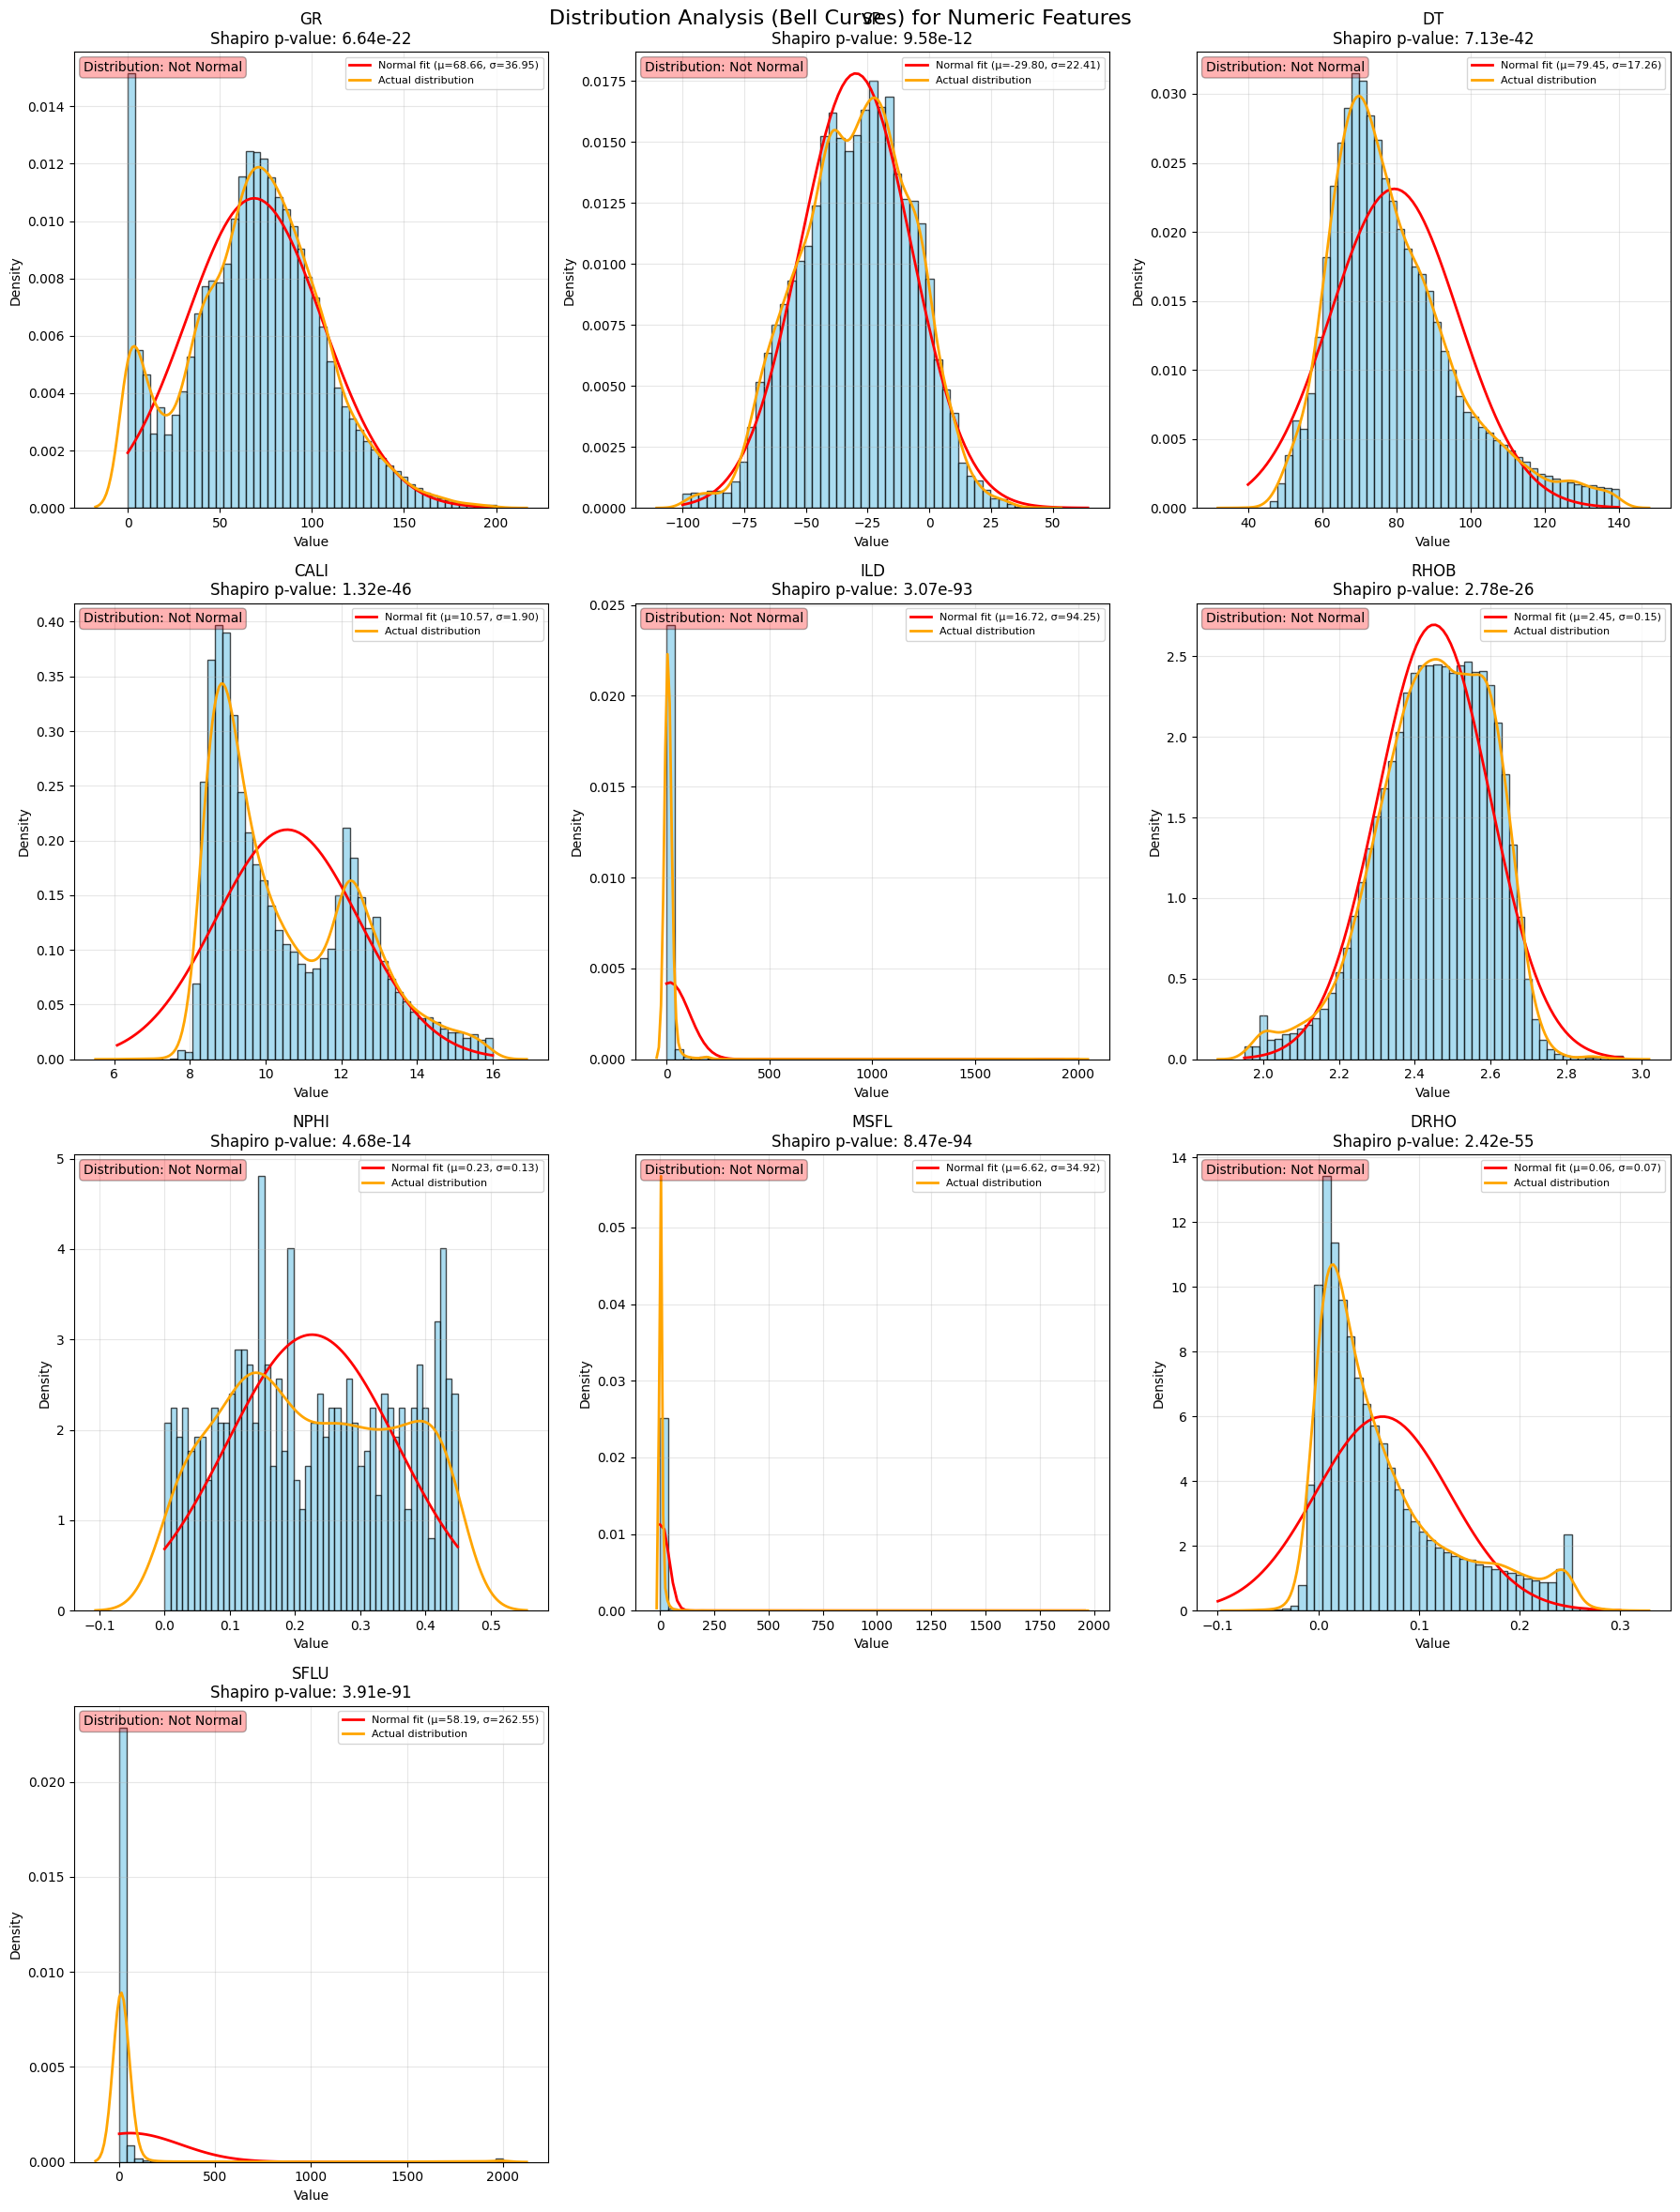


Normality Test Summary:
Shapiro-Wilk Test Results (p > 0.05 suggests normal distribution):

  Feature  Sample_Size  Shapiro_Statistic  P_Value Is_Normal
0      GR         5000           0.984154      0.0        No
1      SP         5000           0.995748      0.0        No
2      DT         5000           0.935368      0.0        No
3    CALI         5000           0.915617      0.0        No
4     ILD         5000           0.087916      0.0        No
5    RHOB         5000           0.980833      0.0        No
6    NPHI          694           0.953115      0.0        No
7    MSFL         5000           0.173253      0.0        No
8    DRHO         5000           0.848207      0.0        No
9    SFLU         5000           0.182935      0.0        No


In [31]:
import seaborn as sns
from scipy import stats

# Create histograms (bell curves) to check for normal distribution
import matplotlib.pyplot as plt

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Calculate number of filtered numeric columns and create subplots
n_cols_dist = len(filtered_numeric_columns_clean)
n_rows_dist = (n_cols_dist + 2) // 3  # 3 columns per row
fig, axes = plt.subplots(n_rows_dist, 3, figsize=(18, 6 * n_rows_dist))
fig.suptitle('Distribution Analysis (Bell Curves) for Numeric Features', fontsize=16, y=0.98)

# Handle single subplot case
if n_cols_dist == 1:
    axes = [axes]
elif n_rows_dist == 1:
    axes = axes if n_cols_dist > 1 else [axes]
else:
    axes = axes.flatten()

# Create distribution plots
for i, col in enumerate(filtered_numeric_columns_clean):
    ax = axes[i] if n_cols_dist > 1 else axes[0]
    
    # Get data for the column (remove NaN values)
    data = df_features_filtered[col].dropna()
    
    if len(data) > 0:
        # Create histogram with density curve
        ax.hist(data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        
        # Overlay normal distribution curve
        mu, sigma = stats.norm.fit(data)
        x = np.linspace(data.min(), data.max(), 100)
        normal_curve = stats.norm.pdf(x, mu, sigma)
        ax.plot(x, normal_curve, 'r-', linewidth=2, label=f'Normal fit (μ={mu:.2f}, σ={sigma:.2f})')
        
        # Overlay actual kernel density estimate
        data_sample = data.sample(min(10000, len(data)))  # Sample for performance
        sns.kdeplot(data=data_sample, ax=ax, color='orange', linewidth=2, label='Actual distribution')
        
        # Perform Shapiro-Wilk test for normality (on sample if data is large)
        sample_size = min(5000, len(data))  # Shapiro-Wilk works best with smaller samples
        data_sample_test = data.sample(sample_size) if len(data) > sample_size else data
        shapiro_stat, shapiro_p = stats.shapiro(data_sample_test)
        
        # Set title and labels
        ax.set_title(f'{col}\nShapiro p-value: {shapiro_p:.2e}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Add interpretation text
        if shapiro_p > 0.05:
            normality_text = "Likely Normal"
            text_color = 'green'
        else:
            normality_text = "Not Normal"
            text_color = 'red'
        
        ax.text(0.02, 0.98, f'Distribution: {normality_text}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor=text_color, alpha=0.3))
    else:
        ax.text(0.5, 0.5, f'No data available for {col}', 
                transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f'{col} - No Data')

# Hide unused subplots
for i in range(len(filtered_numeric_columns_clean), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary of normality tests
print("\nNormality Test Summary:")
print("=" * 50)
print("Shapiro-Wilk Test Results (p > 0.05 suggests normal distribution):\n")

normality_results = []
for col in filtered_numeric_columns_clean:
    data = df_features_filtered[col].dropna()
    if len(data) > 3:  # Minimum required for Shapiro-Wilk
        sample_size = min(5000, len(data))
        data_sample = data.sample(sample_size) if len(data) > sample_size else data
        shapiro_stat, shapiro_p = stats.shapiro(data_sample)
        
        normality_results.append({
            'Feature': col,
            'Sample_Size': len(data_sample),
            'Shapiro_Statistic': shapiro_stat,
            'P_Value': shapiro_p,
            'Is_Normal': 'Yes' if shapiro_p > 0.05 else 'No'
        })

normality_df = pd.DataFrame(normality_results)
print(normality_df.round(6))

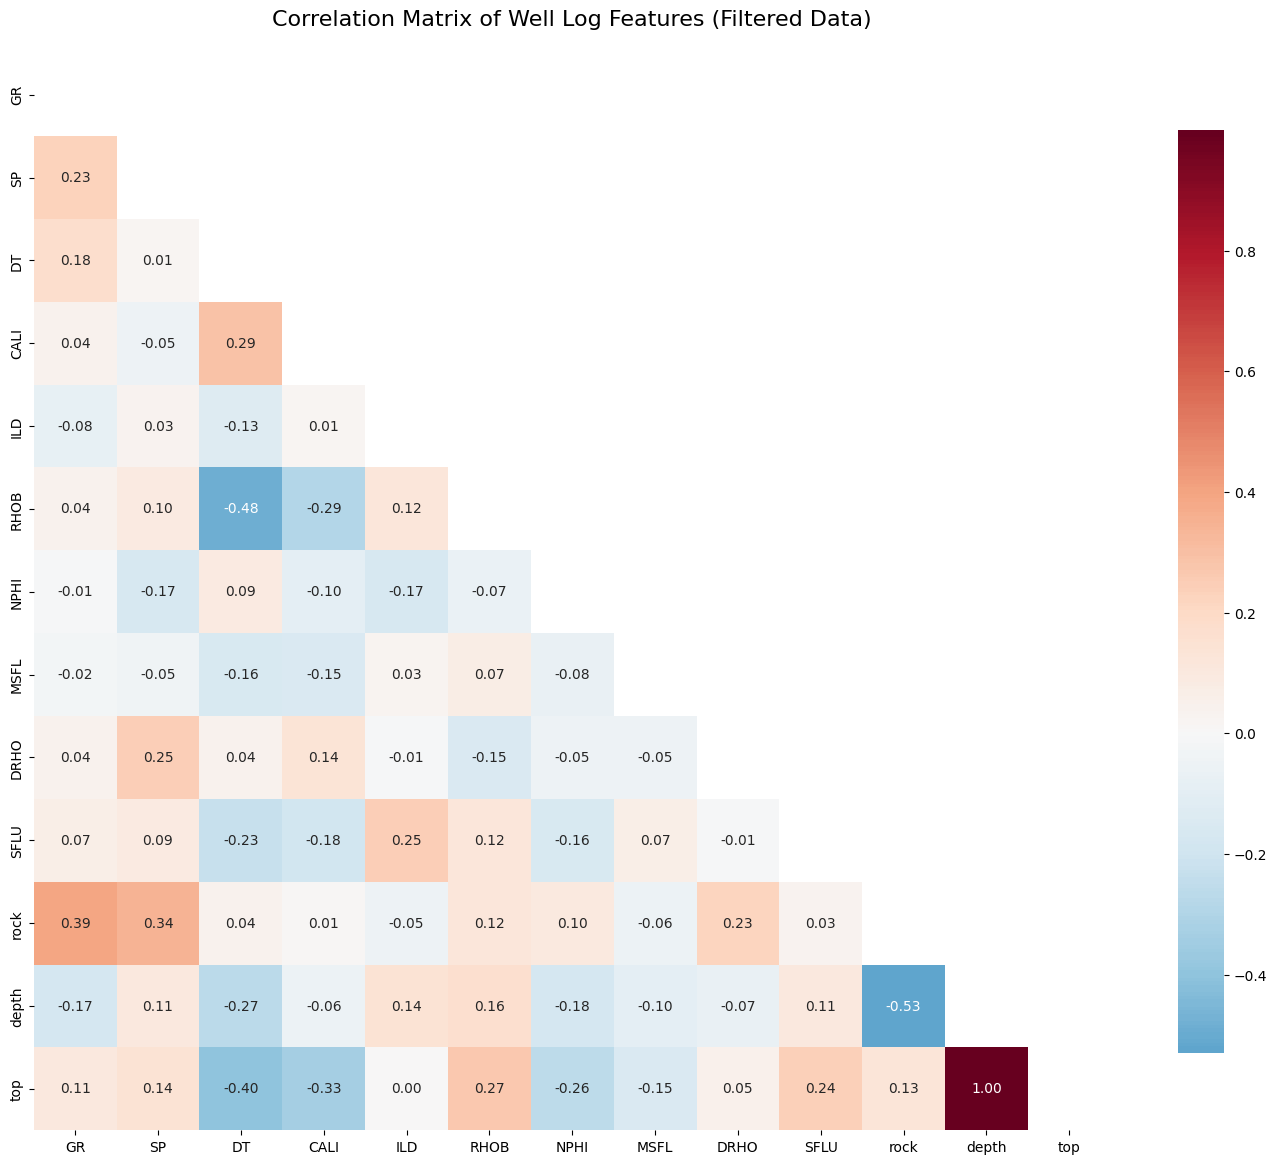


Strong Correlations (|r| > 0.7):

Normal Correlations (|r| > 0.4):

Weak Correlations (|r| > 0.1):
  Feature 1 Feature 2  Correlation
0     depth       top     0.999846

Normal Correlations (|r| > 0.4):
  Feature 1 Feature 2  Correlation
2      rock     depth    -0.530486
0        DT      RHOB    -0.483912
1        DT       top    -0.400910

Weak Correlations (|r| > 0.1):
   Feature 1 Feature 2  Correlation
2         GR      rock     0.392558
7         SP      rock     0.342870
19      CALI       top    -0.334062
10        DT      CALI     0.294146
15      CALI      RHOB    -0.285492
14        DT     depth    -0.267851
28      RHOB       top     0.266029
32      NPHI       top    -0.259710
22       ILD      SFLU     0.251779
6         SP      DRHO     0.248781
36      SFLU       top     0.239943
0         GR        SP     0.231564
34      DRHO      rock     0.226530
13        DT      SFLU    -0.226249
18      CALI      SFLU    -0.184845
31      NPHI     depth    -0.177389
1         GR

In [32]:
columns = filtered_numeric_columns_clean.copy()
columns.extend(["rock", "depth", "top"])
df_features_cleaned = df_features_filtered.copy()
df_features_cleaned["rock"] = df_features_filtered["rock"].astype('category').cat.codes
# Create correlation matrix for numeric columns in the filtered dataset
correlation_matrix = df_features_cleaned[columns].corr()

# Create heatmap using matplotlib and seaborn
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Well Log Features (Filtered Data)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Print strong correlations (absolute value > 0.7)
print("\nStrong Correlations (|r| > 0.7):")
print("\nNormal Correlations (|r| > 0.4):")
print("\nWeak Correlations (|r| > 0.1):")
print("=" * 50)
strong_corr = []
normal_corr = []
weak_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            strong_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })
        elif abs(corr_value) > 0.4:
            normal_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })
        elif abs(corr_value) > 0.1:
            weak_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
    print(strong_corr_df)
else:
    print("No strong correlations found (|r| > 0.7)")
    
if normal_corr:
    normal_corr_df = pd.DataFrame(normal_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\nNormal Correlations (|r| > 0.4):")
    print(normal_corr_df)
else:
    print("No normal correlations found (|r| > 0.4)")
if weak_corr:
    weak_corr_df = pd.DataFrame(weak_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\nWeak Correlations (|r| > 0.1):")
    print(weak_corr_df)
else:
    print("No weak correlations found (|r| > 0.1)")

## Target column analysis
The target column "rock" represents different rock types in the dataset. Analyzing the distribution of rock types is crucial for understanding the geological characteristics of the wells. The following steps were taken to analyze the target column:
1. **Distribution Analysis**:
    - Calculated the frequency of each rock type using value counts.
    - Calculated the percentage representation of each rock type by well.
2. **Visualization**:
    - Visualized the distribution using bar plots or pie charts to identify the most common rock types.

Rock Type Distribution Analysis:

Rock Type Frequency:
        Rock_Type   Count  Percentage
0        FOLHELHO  323879       42.41
1         ARENITO  278184       36.43
2         SILTITO   62312        8.16
3        ARGILITO   30446        3.99
4     CALCILUTITO   28771        3.77
5           AREIA    8235        1.08
6     CALCARENITO    6894        0.90
7          ARGILA    5886        0.77
8        CALCARIO    5091        0.67
9    CONGLOMERADO    4934        0.65
10        GRANITO    2797        0.37
11         HALITA    2484        0.33
12       ANIDRITA    1433        0.19
13       DOLOMITO    1083        0.14
14        BASALTO     776        0.10
15          MARGA     223        0.03
16  CALCISSILTITO     112        0.01
17      QUARTZITO      74        0.01
18    ACINZENTADO      49        0.01
19          CINZA      30        0.00
20         BRECHA      15        0.00


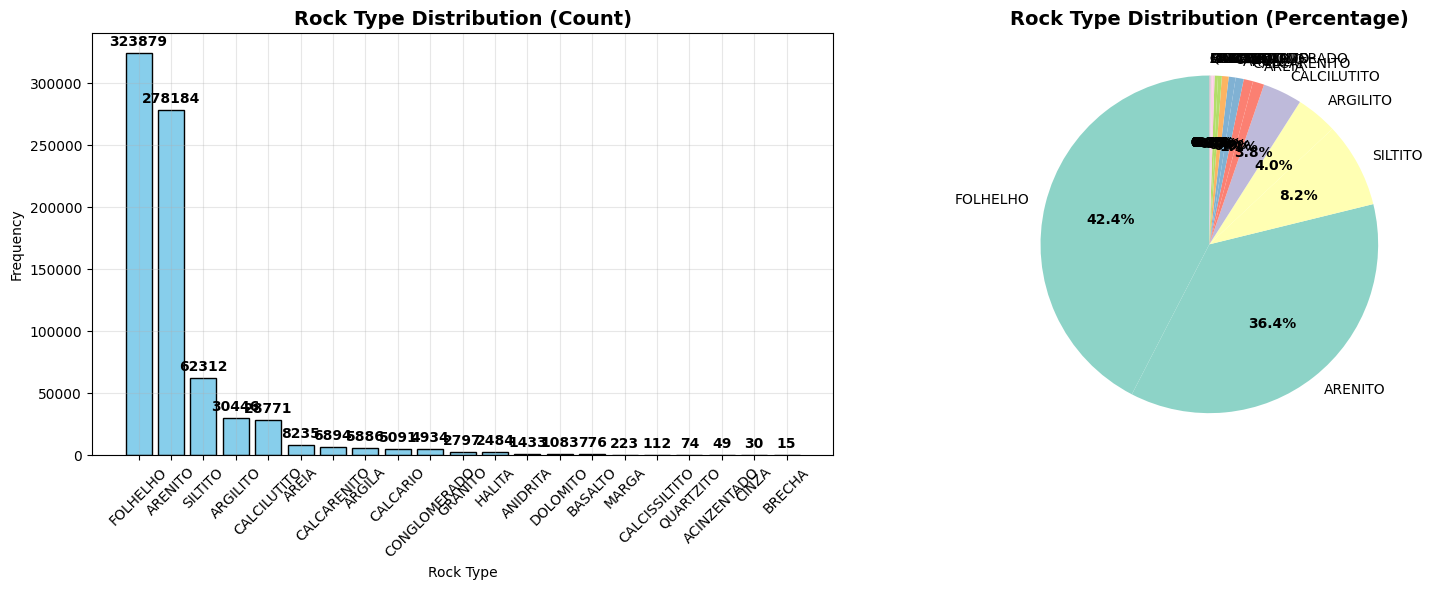


Summary Statistics:
Total number of rock type records: 763,708
Number of unique rock types: 21
Most common rock type: FOLHELHO (323,879 records, 42.4%)
Least common rock type: BRECHA (15 records, 0.0%)


In [33]:
# Analyze the distribution of rock types
print("Rock Type Distribution Analysis:")
print("=" * 50)

# Get rock type value counts
rock_counts = df_features_filtered['rock'].value_counts()
rock_percentages = (rock_counts / rock_counts.sum()) * 100

# Create a summary dataframe
rock_distribution = pd.DataFrame({
    'Rock_Type': rock_counts.index,
    'Count': rock_counts.values,
    'Percentage': rock_percentages.values
})

print("\nRock Type Frequency:")
print(rock_distribution.round(2))

# Create frequency chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax1.bar(rock_distribution['Rock_Type'], rock_distribution['Count'], color='skyblue', edgecolor='black')
ax1.set_title('Rock Type Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Rock Type')
ax1.set_ylabel('Frequency')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Add count labels on bars
for i, v in enumerate(rock_distribution['Count']):
    ax1.text(i, v + max(rock_distribution['Count']) * 0.01, str(v), 
             ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(rock_distribution)))
wedges, texts, autotexts = ax2.pie(rock_distribution['Percentage'], 
                                   labels=rock_distribution['Rock_Type'],
                                   autopct='%1.1f%%',
                                   colors=colors,
                                   startangle=90)
ax2.set_title('Rock Type Distribution (Percentage)', fontsize=14, fontweight='bold')

# Enhance pie chart text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics:")
print(f"Total number of rock type records: {rock_counts.sum():,}")
print(f"Number of unique rock types: {len(rock_counts)}")
print(f"Most common rock type: {rock_counts.index[0]} ({rock_counts.iloc[0]:,} records, {rock_percentages.iloc[0]:.1f}%)")
print(f"Least common rock type: {rock_counts.index[-1]} ({rock_counts.iloc[-1]:,} records, {rock_percentages.iloc[-1]:.1f}%)")

In [ ]:
"""
15         HALITA            2              3.17
16  CALCISSILTITO            2              3.17
17      QUARTZITO            2              3.17
18          CINZA            2              3.17
19    ACINZENTADO            1              1.59
20         BRECHA            1              1.59
"""

,well,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,DRHO,SFLU,top,bottom,rock
0,1BT2AM,270.0,63.279785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
1,1BT2AM,270.2,62.580566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
2,1BT2AM,270.4,64.454590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
3,1BT2AM,270.6,65.624268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
4,1BT2AM,270.8,64.920898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,3PIR7AL,1788.2,105.457748,-3.301666,74.474747,NaN,4.499398,NaN,NaN,NaN,NaN,4.040940,1782.0,1790.0,FOLHELHO
999996,3PIR7AL,1788.4,98.367188,-5.609985,69.902344,NaN,4.501740,NaN,NaN,NaN,NaN,5.707031,1782.0,1790.0,FOLHELHO
999997,3PIR7AL,1788.6,98.895508,-6.745575,69.823212,NaN,4.713235,NaN,NaN,NaN,NaN,7.059439,1782.0,1790.0,FOLHELHO
999998,3PIR7AL,1788.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1782.0,1790.0,FOLHELHO


Rock Type Distribution by Number of Wells:

Rock Type by Wells Frequency:
        Rock_Type  Wells_Count  Wells_Percentage
0         ARENITO           63            100.00
1        FOLHELHO           63            100.00
2         SILTITO           60             95.24
3     CALCILUTITO           58             92.06
4           AREIA           34             53.97
5     CALCARENITO           32             50.79
6          ARGILA           29             46.03
7        CALCARIO           10             15.87
8    CONGLOMERADO            9             14.29
9        ARGILITO            8             12.70
10       ANIDRITA            8             12.70
11          MARGA            6              9.52
12        GRANITO            3              4.76
13        BASALTO            3              4.76
14       DOLOMITO            3              4.76
15         HALITA            2              3.17
16  CALCISSILTITO            2              3.17
17      QUARTZITO            2              

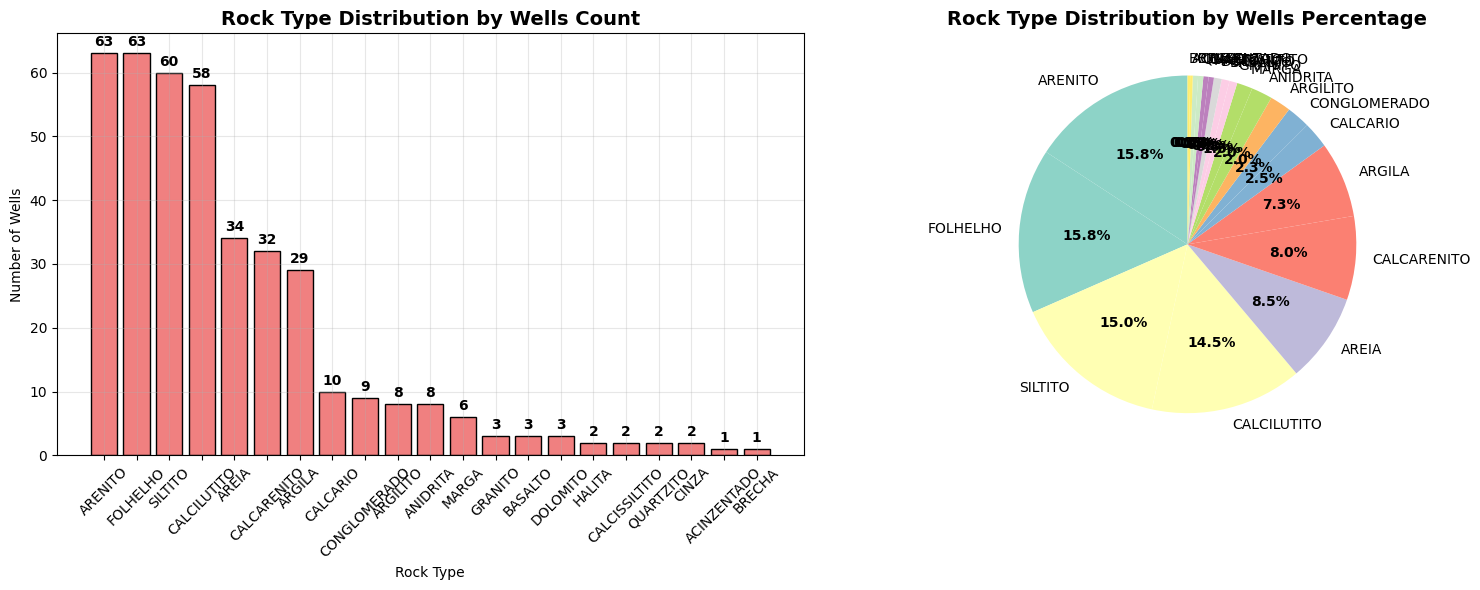


Summary Statistics:
Total number of unique wells: 63
Number of unique rock types: 21
Most common rock type by wells: ARENITO (63 wells, 100.0%)
Least common rock type by wells: BRECHA (1 wells, 1.6%)


In [45]:
# Analyze rock type distribution by distinct wells
print("Rock Type Distribution by Number of Wells:")
print("=" * 50)

# Count distinct wells for each rock type
rock_well_counts = df_features_filtered.groupby('rock')['well'].nunique().sort_values(ascending=False)
rock_well_percentages = (rock_well_counts / df_features_filtered['well'].nunique()) * 100

# Create a summary dataframe
rock_well_distribution = pd.DataFrame({
    'Rock_Type': rock_well_counts.index,
    'Wells_Count': rock_well_counts.values,
    'Wells_Percentage': rock_well_percentages.values
})

print("\nRock Type by Wells Frequency:")
print(rock_well_distribution.round(2))

# Create frequency chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax1.bar(rock_well_distribution['Rock_Type'], rock_well_distribution['Wells_Count'], 
        color='lightcoral', edgecolor='black')
ax1.set_title('Rock Type Distribution by Wells Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Rock Type')
ax1.set_ylabel('Number of Wells')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Add count labels on bars
for i, v in enumerate(rock_well_distribution['Wells_Count']):
    ax1.text(i, v + max(rock_well_distribution['Wells_Count']) * 0.01, str(v), 
             ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(rock_well_distribution)))
wedges, texts, autotexts = ax2.pie(rock_well_distribution['Wells_Percentage'], 
                                   labels=rock_well_distribution['Rock_Type'],
                                   autopct='%1.1f%%',
                                   colors=colors,
                                   startangle=90)
ax2.set_title('Rock Type Distribution by Wells Percentage', fontsize=14, fontweight='bold')

# Enhance pie chart text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

# Print summary statistics
total_wells = df_features_filtered['well'].nunique()
print(f"\nSummary Statistics:")
print(f"Total number of unique wells: {total_wells}")
print(f"Number of unique rock types: {len(rock_well_counts)}")
print(f"Most common rock type by wells: {rock_well_counts.index[0]} ({rock_well_counts.iloc[0]} wells, {rock_well_percentages.iloc[0]:.1f}%)")
print(f"Least common rock type by wells: {rock_well_counts.index[-1]} ({rock_well_counts.iloc[-1]} wells, {rock_well_percentages.iloc[-1]:.1f}%)")

In [36]:
# Add boolean columns indicating null values for each numeric column
for col in numeric_columns:
    df_features_filtered[f'{col}_is_null'] = df_features_filtered[col].isnull().astype(int)

# Display the updated dataframe with null indicator columns
print("Added null indicator columns:")
print(df_features_filtered.columns.tolist())
print("\nDataframe shape:", df_features_filtered.shape)
print("\nSample of null indicator columns:")
null_indicator_cols = [col for col in df_features_filtered.columns if col.endswith('_is_null')]
print(df_features_filtered[null_indicator_cols].head())

Added null indicator columns:
['well', 'depth', 'GR', 'SP', 'DT', 'CALI', 'ILD', 'RHOB', 'NPHI', 'MSFL', 'DRHO', 'SFLU', 'top', 'bottom', 'rock', 'depth_is_null', 'GR_is_null', 'SP_is_null', 'DT_is_null', 'CALI_is_null', 'ILD_is_null', 'RHOB_is_null', 'NPHI_is_null', 'MSFL_is_null', 'DRHO_is_null', 'SFLU_is_null', 'top_is_null', 'bottom_is_null']

Dataframe shape: (1000000, 28)

Sample of null indicator columns:
   depth_is_null  GR_is_null  SP_is_null  DT_is_null  CALI_is_null  \
0              0           0           1           1             1   
1              0           0           1           1             1   
2              0           0           1           1             1   
3              0           0           1           1             1   
4              0           0           1           1             1   

   ILD_is_null  RHOB_is_null  NPHI_is_null  MSFL_is_null  DRHO_is_null  \
0            1             1             1             1             1   
1            1 

In [37]:
df_features_filtered.columns
#df_features.columns

Index(['well', 'depth', 'GR', 'SP', 'DT', 'CALI', 'ILD', 'RHOB', 'NPHI',
       'MSFL', 'DRHO', 'SFLU', 'top', 'bottom', 'rock', 'depth_is_null',
       'GR_is_null', 'SP_is_null', 'DT_is_null', 'CALI_is_null', 'ILD_is_null',
       'RHOB_is_null', 'NPHI_is_null', 'MSFL_is_null', 'DRHO_is_null',
       'SFLU_is_null', 'top_is_null', 'bottom_is_null'],
      dtype='object')

In [38]:
from sklearn.model_selection import train_test_split

# Get unique wells
unique_wells = df_features_filtered['well'].unique() if 'well' in df_features_filtered.columns else df_features['well'].unique()

# Split wells into train and test (80-20 split)
train_wells, test_wells = train_test_split(unique_wells, test_size=0.2, random_state=42)

# Select the required columns
selected_columns = ['depth', 'GR', 'SP', 'DT', 'CALI', 'ILD', 'RHOB', 'NPHI', 'MSFL', 'DRHO', 'SFLU', 
                   'GR_is_null', 'SP_is_null', 'DT_is_null', 'CALI_is_null', 'ILD_is_null', 
                   'RHOB_is_null', 'NPHI_is_null', 'MSFL_is_null', 'DRHO_is_null', 'SFLU_is_null', 'rock']

# Get well column from original dataframe and create train/test splits
#df_with_well = df_features[['well']].join(df_features_filtered[selected_columns])

# Create train and test datasets based on well splits
train_data = df_features_filtered[df_features_filtered['well'].isin(train_wells)][selected_columns]
test_data = df_features_filtered[df_features_filtered['well'].isin(test_wells)][selected_columns]

print(f"Total unique wells: {len(unique_wells)}")
print(f"Training wells: {len(train_wells)}")
print(f"Testing wells: {len(test_wells)}")
print(f"\nTraining data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")
print(f"\nSelected columns: {selected_columns}")

Total unique wells: 63
Training wells: 50
Testing wells: 13

Training data shape: (711025, 22)
Testing data shape: (288975, 22)

Selected columns: ['depth', 'GR', 'SP', 'DT', 'CALI', 'ILD', 'RHOB', 'NPHI', 'MSFL', 'DRHO', 'SFLU', 'GR_is_null', 'SP_is_null', 'DT_is_null', 'CALI_is_null', 'ILD_is_null', 'RHOB_is_null', 'NPHI_is_null', 'MSFL_is_null', 'DRHO_is_null', 'SFLU_is_null', 'rock']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   well    1000000 non-null  object 
 1   depth   1000000 non-null  float64
 2   GR      663835 non-null   float64
 3   SP      559598 non-null   float64
 4   DT      274282 non-null   float64
 5   CALI    405858 non-null   float64
 6   ILD     484782 non-null   float64
 7   RHOB    359782 non-null   float64
 8   NPHI    694 non-null      float64
 9   MSFL    20697 non-null    float64
 10  DRHO    360807 non-null   float64
 11  SFLU    211845 non-null   float64
 12  top     763708 non-null   float64
 13  bottom  763708 non-null   float64
 14  rock    763708 non-null   object 
dtypes: float64(13), object(2)
memory usage: 114.4+ MB
